# **AFCON 2023 Tournament Dashboard**

This dashboard presents the main findings from the AFCON 2023 match analysis.

In [1]:
# Import libraries and load the cleaned match data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

matches_clean = pd.read_csv('afcon_matches_2023.csv')
matches_clean['result'] = 'Draw'
matches_clean.loc[matches_clean['home_score'] > matches_clean['away_score'], 'result'] = 'Home Win'
matches_clean.loc[matches_clean['home_score'] < matches_clean['away_score'], 'result'] = 'Away Win'
matches_clean['total_goals'] = matches_clean['home_score'] + matches_clean['away_score']
matches_clean['both_teams_scored'] = (matches_clean['home_score'] > 0) & (matches_clean['away_score'] > 0)

sns.set_theme(style='whitegrid')

In [2]:
# Build the summary tables used by the dashboard
home_summary = matches_clean[['home_team', 'home_score', 'away_score', 'result']].rename(
    columns={'home_team': 'team', 'home_score': 'goals_for', 'away_score': 'goals_against'}
)
home_summary['win'] = home_summary['result'].eq('Home Win')
home_summary['draw'] = home_summary['result'].eq('Draw')
home_summary['loss'] = home_summary['result'].eq('Away Win')

away_summary = matches_clean[['away_team', 'away_score', 'home_score', 'result']].rename(
    columns={'away_team': 'team', 'away_score': 'goals_for', 'home_score': 'goals_against'}
)
away_summary['win'] = away_summary['result'].eq('Away Win')
away_summary['draw'] = away_summary['result'].eq('Draw')
away_summary['loss'] = away_summary['result'].eq('Home Win')

team_summary = pd.concat([home_summary, away_summary], ignore_index=True).groupby('team', as_index=False).agg(
    matches_played=('team', 'size'),
    wins=('win', 'sum'),
    draws=('draw', 'sum'),
    losses=('loss', 'sum'),
    goals_for=('goals_for', 'sum'),
    goals_against=('goals_against', 'sum')
)
team_summary['goal_difference'] = team_summary['goals_for'] - team_summary['goals_against']
team_summary['points'] = (team_summary['wins'] * 3) + team_summary['draws']
team_summary = team_summary.sort_values(['points', 'goal_difference', 'goals_for'], ascending=False).reset_index(drop=True)

result_summary = matches_clean['result'].value_counts().rename_axis('result').reset_index(name='matches')
stage_summary = matches_clean.groupby('competition_stage', as_index=False).agg(
    matches=('match_id', 'count'),
    total_goals=('total_goals', 'sum'),
    average_goals=('total_goals', 'mean')
)
stage_order = ['Group Stage', 'Round of 16', 'Quarter-finals', 'Semi-finals', '3rd Place Final', 'Final']
stage_summary['competition_stage'] = pd.Categorical(stage_summary['competition_stage'], categories=stage_order, ordered=True)
stage_summary = stage_summary.sort_values('competition_stage')


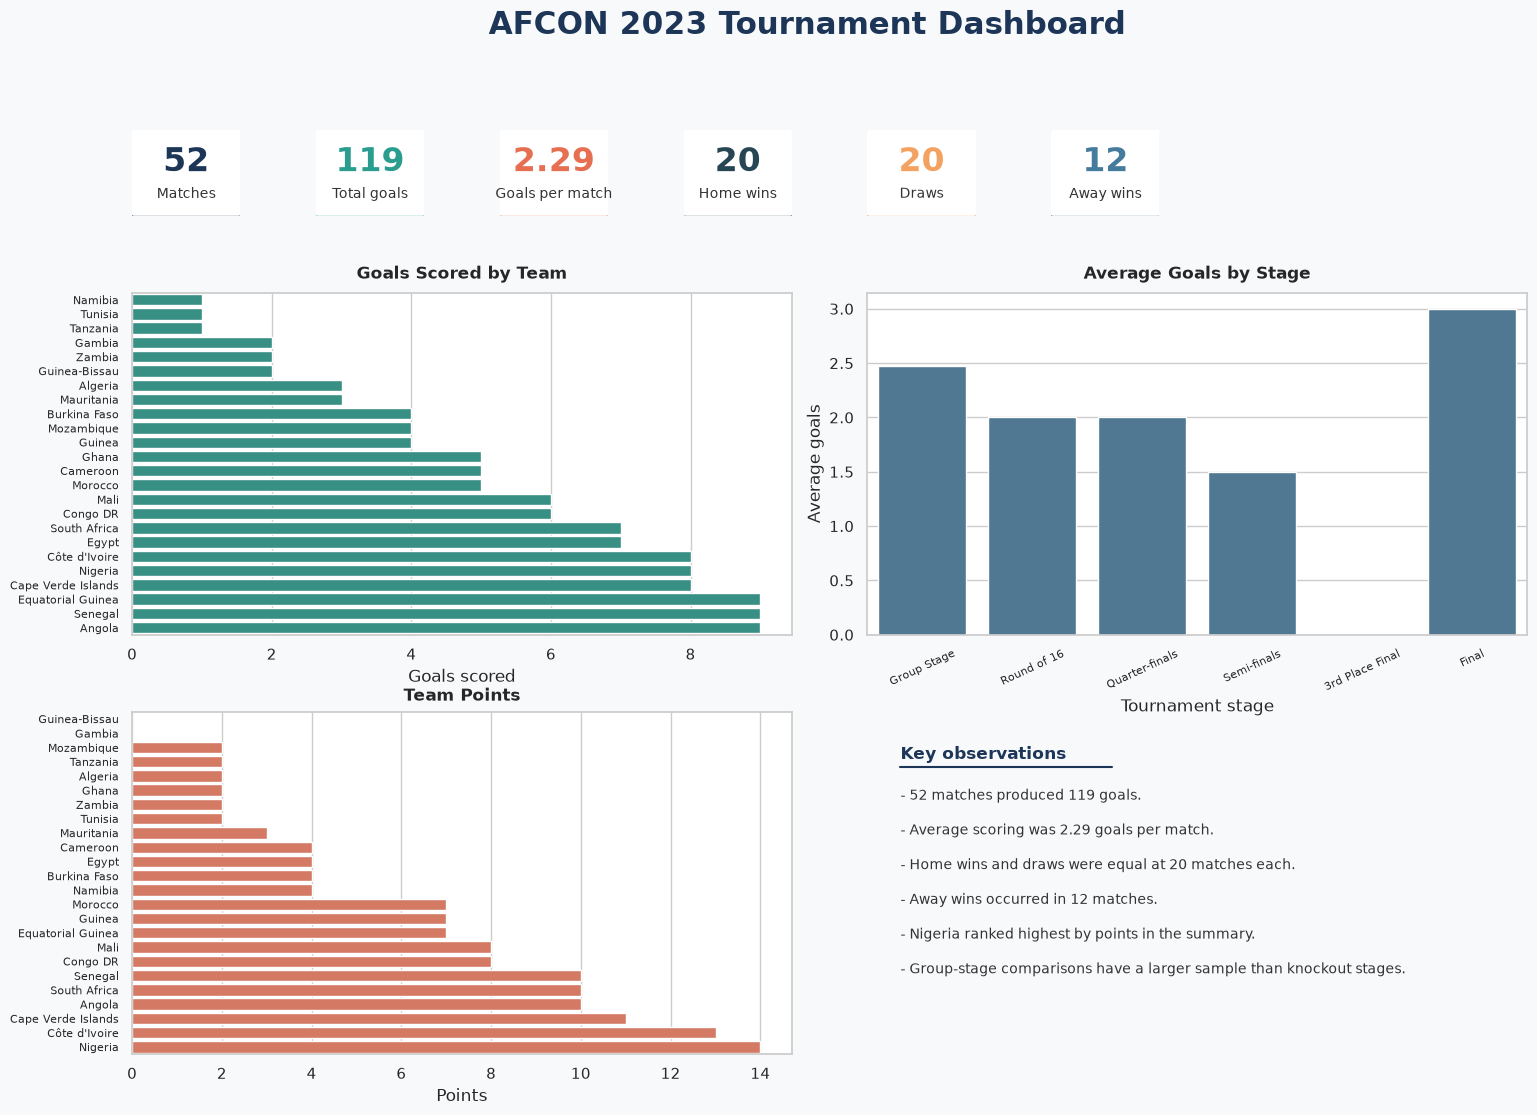

In [7]:
# Create the one-page tournament dashboard
plt.close('all')
fig = plt.figure(figsize=(18, 12), facecolor='#f7f9fb')
grid = fig.add_gridspec(
    nrows=3,
    ncols=8,
    height_ratios=[0.8, 3.2, 3.2],
    hspace=0.3,
    wspace=0.7
)

fig.suptitle(
    'AFCON 2023 Tournament Dashboard',
    fontsize=22,
    fontweight='bold',
    color='#1d3557',
    y=0.98
)

home_wins = int(result_summary.loc[result_summary['result'].eq('Home Win'), 'matches'].iloc[0])
draws = int(result_summary.loc[result_summary['result'].eq('Draw'), 'matches'].iloc[0])
away_wins = int(result_summary.loc[result_summary['result'].eq('Away Win'), 'matches'].iloc[0])
metrics = [
    ('Matches', len(matches_clean), '#1d3557'),
    ('Total goals', int(matches_clean['total_goals'].sum()), '#2a9d8f'),
    ('Goals per match', round(matches_clean['total_goals'].mean(), 2), '#e76f51'),
    ('Home wins', home_wins, '#264653'),
    ('Draws', draws, '#f4a261'),
    ('Away wins', away_wins, '#457b9d')
]

for index, (label, value, color) in enumerate(metrics):
    axis = fig.add_subplot(grid[0, index])
    axis.set_facecolor('white')
    axis.add_patch(FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle='round,pad=0.02,rounding_size=0.04',
        transform=axis.transAxes,
        facecolor='white',
        edgecolor=color,
        linewidth=2
    ))
    axis.text(0.5, 0.62, str(value), ha='center', va='center', fontsize=24, fontweight='bold', color=color)
    axis.text(0.5, 0.25, label, ha='center', va='center', fontsize=10, color='#333333')
    axis.set_axis_off()

team_goals = team_summary.sort_values('goals_for', ascending=True)
axis_goals = fig.add_subplot(grid[1, :4])
sns.barplot(data=team_goals, x='goals_for', y='team', color='#2a9d8f', ax=axis_goals)
axis_goals.set_title('Goals Scored by Team', fontweight='bold', pad=10)
axis_goals.set_xlabel('Goals scored')
axis_goals.set_ylabel('')
axis_goals.tick_params(axis='y', labelsize=8)

stage_goals = stage_summary.copy()
axis_stage = fig.add_subplot(grid[1, 4:])
sns.barplot(data=stage_goals, x='competition_stage', y='average_goals', color='#457b9d', ax=axis_stage)
axis_stage.set_title('Average Goals by Stage', fontweight='bold', pad=10)
axis_stage.set_xlabel('Tournament stage')
axis_stage.set_ylabel('Average goals')
axis_stage.tick_params(axis='x', rotation=25, labelsize=8)

team_points = team_summary.sort_values('points', ascending=True)
axis_points = fig.add_subplot(grid[2, :4])
sns.barplot(data=team_points, x='points', y='team', color='#e76f51', ax=axis_points)
axis_points.set_title('Team Points', fontweight='bold', pad=8)
axis_points.set_xlabel('Points')
axis_points.set_ylabel('')
axis_points.tick_params(axis='y', labelsize=8)

axis_notes = fig.add_subplot(grid[2, 4:])
axis_notes.set_facecolor('#fffaf0')
axis_notes.axis('off')
axis_notes.text(
    0.05,
    0.9,
    'Key observations',
    va='top',
    fontsize=12,
    fontweight='bold',
    color='#1d3557',
    transform=axis_notes.transAxes,
    usetex=False
)
axis_notes.text(
    0.05,
    0.78,
    '\n\n'.join([
        f'- {len(matches_clean)} matches produced {int(matches_clean["total_goals"].sum())} goals.',
        f'- Average scoring was {matches_clean["total_goals"].mean():.2f} goals per match.',
        f'- Home wins and draws were equal at {home_wins} matches each.',
        f'- Away wins occurred in {away_wins} matches.',
        f'- {team_summary.iloc[0]["team"]} ranked highest by points in the summary.',
        '- Group-stage comparisons have a larger sample than knockout stages.'
    ]),
    va='top',
    fontsize=10,
    color='#333333',
    linespacing=1.25,
    transform=axis_notes.transAxes
)
axis_notes.plot(
    [0.05, 0.37],
    [0.84, 0.84],
    color='#1d3557',
    linewidth=1.5,
    transform=axis_notes.transAxes,
    clip_on=False
)

plt.show()